 ## Домашнее задание Проверка гипотез

In [ ]:
from scipy import stats
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<div class="alert alert-info">
<b>Задание № 1</b>
    
Разработайте функцию для проверки нормальности распределения выборки данных, используя шаблон ниже. Вы можете использовать один из известных Вам статистических тестов.
</div>

In [ ]:
def check_normality(data):
    stat, p = stats.shapiro(data)
    alpha = 0.05
    if p < alpha:
        print("Отклоняем нулевую гипотезу >> Данные распределены не нормально")
    else:
        print("Не отклоняем нулевую гипотезу >> Данные распределены нормально")

<div class="alert alert-info">
<b>Задание № 2</b>

Даны две выборки роста мужчин и женщин.
- Докажите, используя `t-Тест Стьдента`, что различие между выборками незначительно, если уровень значимости равен $\alpha$ `= 0.001`.
- Покажите различия визуально
- Является ли результат полезным с практической точки зрения? Почему да или нет?
</div>

In [ ]:
np.random.seed(42) #фиксация случайности

mens  = stats.norm.rvs(loc=171, scale=10, size=150000)  # Выборка мужчин со средним ростом 171
womens = stats.norm.rvs(loc=170, scale=10, size=150000)  # Выборка женщин со средним ростом 170

In [ ]:
stat, p = stats.ttest_ind(mens, womens)
alpha = 0.001
if p < alpha:
  print("Отклоняем нулевую гипотезу >> Различие между выборками статистически значимо")
else:
  print("Не отклоняем нулевую гипотезу >> Выборки не имеют статистически значимых различий")

Отклоняем нулевую гипотезу >> Различие между выборками статистически значимо


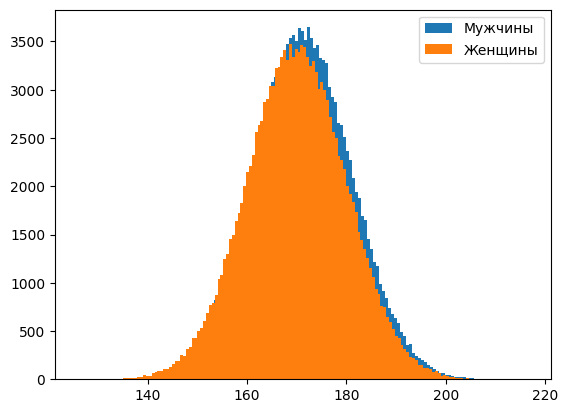

In [ ]:
plt.hist(mens, bins=150, label='Мужчины')
plt.hist(womens, bins=150, label='Женщины')
plt.legend()
plt.show()

Вывод: из-за больших размеров выборки тест становится чувствительным даже к незначительным различиям и показывает стат значимый результат

<div class="alert alert-info">
<b>Задание № 3</b>

Специалист по кадрам, работающий в технологической компании, интересуется сверхурочным временем разных команд. Чтобы выяснить, есть ли разница между сверхурочной работой команды разработчиков программного обеспечения и группы тестирования, она случайным образом выбрала 17 сотрудников в каждой из двух команд и записала их среднее сверхурочное время за неделю в пересчете на час. Данные ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между переутомлением двух команд, используя уровень значимости 0,05. Прежде чем приступать к проверке гипотез, проверьте предположение нормальности.
</div>

In [ ]:
test_team = [6.2, 7.1, 1.5, 2,3 , 2, 1.5, 6.1, 2.4, 2.3, 12.4, 1.8, 5.3, 3.1, 9.4, 2.3, 4.1]
developer_team = [2.3, 2.1, 1.4, 2.0, 8.7, 2.2, 3.1, 4.2, 3.6, 2.5, 3.1, 6.2, 12.1, 3.9, 2.2, 1.2 ,3.4]

In [ ]:
check_normality(test_team)
check_normality(developer_team)

Отклоняем нулевую гипотезу >> Данные распределены не нормально
Отклоняем нулевую гипотезу >> Данные распределены не нормально


In [ ]:
stats.levene(test_team, developer_team)

LeveneResult(statistic=0.3819113641351362, pvalue=0.5409557773317198)

Данные распределены НЕнормально и не имеют стат значимых различий >> можем использовать т-тест и тест манна-уитни

In [ ]:
stat, p = stats.ttest_ind(test_team, developer_team)
alpha = 0.05
print('T-test')
if p < alpha:
  print("Отклоняем нулевую гипотезу >> Различие между выборками статистически значимо")
else:
  print("Не отклоняем нулевую гипотезу >> Выборки не имеют статистически значимых различий")

T-test
Не отклоняем нулевую гипотезу >> Выборки не имеют статистически значимых различий


In [ ]:
stat, p = stats.mannwhitneyu(test_team, developer_team)
alpha = 0.05
print('Критерий Манна-Уитни')
if p < alpha:
  print("Отклоняем нулевую гипотезу >> Различие между выборками статистически значимо")
else:
  print("Не отклоняем нулевую гипотезу >> Выборки не имеют статистически значимых различий")

Критерий Манна-Уитни
Не отклоняем нулевую гипотезу >> Выборки не имеют статистически значимых различий


<div class="alert alert-info">
<b>Задание № 4</b>

Педиатр хочет увидеть влияние потребления смеси на среднемесячную прибавку в весе у новорожденных. По этой причине она собрала данные из трех разных групп. Первая группа – дети исключительно грудного вскармливания, вторая группа – дети, которых кормят только смесью, и последняя группа – это дети, находящиеся на искусственном вскармливании и на грудном вскармливании. Эти данные приведены ниже.

В соответствии с этой информацией проведите проверку гипотезы, чтобы проверить, есть ли разница между среднемесячным приростом этих трех групп, используя уровень значимости 0,05. Если есть значительная разница, выполните дальнейший анализ, чтобы найти причину разницы.
</div>

In [ ]:
only_breast = [794.1, 716.9, 993. , 724.7, 760.9, 908.2, 659.3 , 690.8, 768.7, 717.3 , 630.7, 729.5, 714.1, 810.3, 583.5, 679.9, 865.1]
only_formula = [898.8, 881.2, 940.2, 966.2, 957.5, 1061.7, 1046.2, 980.4, 895.6, 919.7, 1074.1, 952.5, 796.3, 859.6, 871.1 , 1047.5, 919.1 , 1160.5, 996.9]
both = [976.4, 656.4, 861.2, 706.8, 718.5, 717.1, 759.8, 894.6, 867.6, 805.6, 765.4, 800.3, 789.9, 875.3, 740. , 799.4, 790.3, 795.2 , 823.6, 818.7, 926.8, 791.7, 948.3]

In [ ]:
# так как имеем 3 выборки применим метод ANOVA
stat, p = stats.f_oneway(only_breast, only_formula, both)
alpha = 0.05
if p < alpha:
  print("Отклоняем нулевую гипотезу >> Различие между выборками статистически значимо")
else:
  print("Не отклоняем нулевую гипотезу >> Выборки не имеют статистически значимых различий")

Отклоняем нулевую гипотезу >> Различие между выборками статистически значимо


Статистически значимые различия есть хотя бы между одной парой групп

In [ ]:
# Для того, чтобы понять между какими группами есть различия применим критерий Тьюки
res = stats.tukey_hsd(only_breast, only_formula, both)
alpha = 0.05
print(res)

Tukey's HSD Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)   -209.392     0.000  -281.434  -137.351
 (0 - 2)    -60.129     0.100  -129.149     8.891
 (1 - 0)    209.392     0.000   137.351   281.434
 (1 - 2)    149.264     0.000    82.365   216.162
 (2 - 0)     60.129     0.100    -8.891   129.149
 (2 - 1)   -149.264     0.000  -216.162   -82.365



Из результатов теста Тьюки можно сделать вывод о том, что стат значимые различия есть между 1 и 2 группами, а также между 2 и 3. 1 и 3 группы статзначимых различий не имеют.

То есть прибавка в весе детей, которых кормят только смесью значимо отличается от прибавке в весе детей на грудном и комбинирванном кормлении.